![Logos](img/logos.png)

# 1.5 Multi-model comparison of dust model outputs

#### Objective 

The objective of this notebook is to provide an introductory example for the comparison of data between two dust models.

One of the most important parts of dust modelling is comparing the performance of different models. Having already visualised one dust variable of a single model, we will do a very basic timeseries comparison of two dust models: MONARCH and the SDS-WAS Multi-Model ensemble.

For this comparison, we will set the same latitude and longitude, but we will look at dust optical depth instead of dust concentration.

First, we need to import our libraries and initialise our paths.

In [1]:
import os
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
root_dir = Path('/home/tvintimi/data/providentia/exp_to_interp')
monarch_path = os.path.join(root_dir, "a00c_cirrus/regional/3hourly/od550_dust/od550_dust_2025030312.nc")
multi_path = os.path.join(root_dir, "multi_model/regional/3hourly/od550_dust/od550_dust_2025030400.nc")
lat = 34.667
lon = 33.025

We will repeat the same process as with the timeseries before: we will open our .nc dataset, extract our dust variable, and then subset the dataset using a latitude and longitude from a point of interest.

In [3]:
monarch_ds = xr.open_dataset(monarch_path)
monarch_dod = monarch_ds['od550_dust']
monarch_point = monarch_dod.sel(lat=lat, lon=lon, method='nearest')
monarch_point

<xarray.DataArray 'od550_dust' (time: 29)> Size: 116B
[29 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 232B 2025-03-03T12:00:00 ... 2025-03-07
    lat      float64 8B 34.65
    lon      float64 8B 33.05
Attributes:
    grid_mapping:  crs
    units:         -

In [4]:
sdswas_ds = xr.open_dataset(multi_path)
sdswas_dod = sdswas_ds['OD550_DUST']
sdswas_point = sdswas_dod.sel(latitude=lat, longitude=lon, method='nearest')
sdswas_point

<xarray.DataArray 'OD550_DUST' (time: 25)> Size: 100B
[25 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 200B 2025-03-04 ... 2025-03-07
    latitude   float32 4B 34.75
    longitude  float32 4B 33.25
Attributes:
    description:  Dust AOD at 550 nm
    units:        unitless

Finally, we will repeat the same plotting structure as we had for the previous timeseries. The only change is that, since we have two instances of model data, we will add a second line of `plt.plot()` with our plotting parameters inside.

When we run this plot, one of the first things we can appreciate is the difference in start times: MONARCH starts at 12UTC, whereas the MULTI-MODEL ensemble starts at 00UTC. You can also see the differences in forecasted dust optical depth at this point, with MONARCH having a noticeably higher peak but the MULTI-MODEL ensemble having higher forecasted dust AOD during extended time periods.

In [5]:
monarch_time = monarch_point["time"]
sdswas_time = sdswas_point["time"]

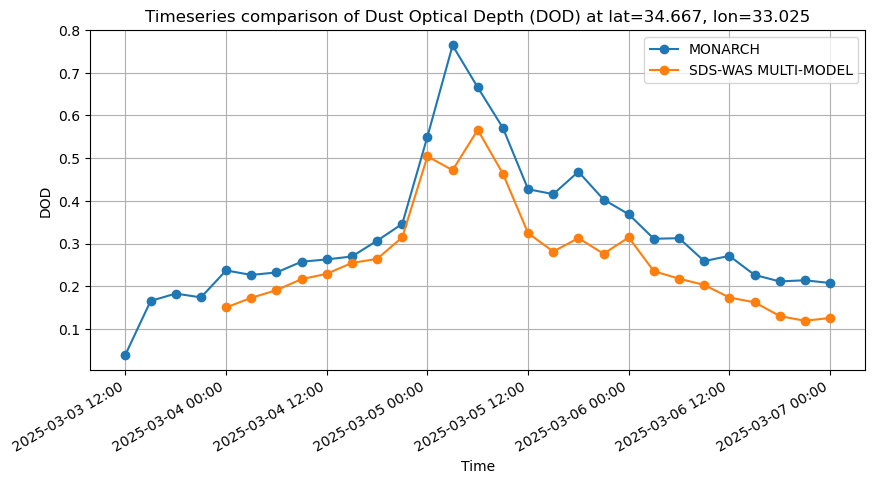

In [6]:
# Plot the time series
plt.figure(figsize=(10,5))
plt.plot(monarch_time, monarch_point, label="MONARCH", marker='o')
plt.plot(sdswas_time, sdswas_point, label="SDS-WAS MULTI-MODEL", marker='o')

# Add plot formatting
plt.xlabel("Time")
plt.ylabel("DOD")
plt.title(f"Timeseries comparison of Dust Optical Depth (DOD) at lat={lat}, lon={lon}")
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.gcf().autofmt_xdate()

# Show the plot
plt.show()

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT1-4-common_operations.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT1-6-Workshop.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr>
</table>